In [1]:
import numpy as np
import anndata as ad

import scanpy as sc
import decoupler as dc
sc.set_figure_params(figsize=(3, 3), frameon=False)

/rds/general/user/ztb25/home/miniforge3/envs/DE/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sc.read("/rds/general/user/ztb25/home/PBMC_datasets/integrated_adata_scANVI.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 880872 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'connectivities_unintegrated', 'distances', 'distances_unintegrated', 'scAN

In [4]:
# Bringing back diagnosis column, needed for composition analysis, that got dropped at concatenation.

# the per-dataset files 
files = {
    "1": "/rds/general/user/ztb25/home/PBMC_datasets/1/PBMC1_clustering.h5ad",
    "4": "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad",
    "5": "/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_clustering.h5ad",
    "6": "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad",
}

diag_map = {}
for ds, path in files.items():
    a = ad.read_h5ad(path, backed="r")
    integrated_barcodes = a.obs_names + f"-{ds}"
    if "diagnosis" in a.obs.columns:
        diags = a.obs["diagnosis"].astype(str).tolist()
    else:
        diags = ["CTRL"] * a.n_obs          # dataset 6 — no column, all controls
    diag_map.update(dict(zip(integrated_barcodes, diags)))
    a.file.close()

adata.obs["diagnosis"] = adata.obs_names.map(diag_map)

In [5]:
import gc
del diag_map                
try:
    del a                    
except NameError:
    pass
gc.collect()

adata.obs["diagnosis"] = adata.obs["diagnosis"].astype("category")


In [6]:
### monocytes lineage

monocytes = ["Classical monocytes", "Non-classical monocytes"]
adata_mono = adata[adata.obs["celltypist_cell_label_fine"].isin(monocytes)].copy()

adata_mono

AnnData object with n_obs × n_vars = 127825 × 12711
    obs: 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'dataset', 'sample_combined', 'diagnosis'
    var: 'feature_types', 'mt', 'gene_symbols', 'genome', 'gene_versions', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'sample_combined_colors', 'scANVI', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_umap_scANVI', 'X_umap_unintegrated'
    varm: 'PCs'
    layers: 'counts', 'log1p_norm'
    obsp: 'connectivities', 'connectivities_unintegrated', 'distances', 'distances_uninteg

In [7]:
# use scanvi latent space to infer pseudotime (batch corrected)

sc.pp.neighbors(adata_mono, use_rep="X_scANVI") # compute neighbors on the corrected latent
sc.tl.diffmap(adata_mono) # generates X_diffmap, which is a trajectory aware dimensionality reduction (distance in diffusion-map space ≈ how likely a cell is to transition into another cell along the manifold.)

# set the root cell for pseudotime inference to be a classical monocyte
adata_mono.uns["iroot"] = np.flatnonzero(
    adata_mono.obs["celltypist_cell_label_fine"] == "Classical monocytes")[0]

# compute pseudotime using diffusion pseudotime (DPT)
sc.tl.dpt(adata_mono) 

# subset-specific umap (for visualisation)
sc.tl.umap(adata_mono)

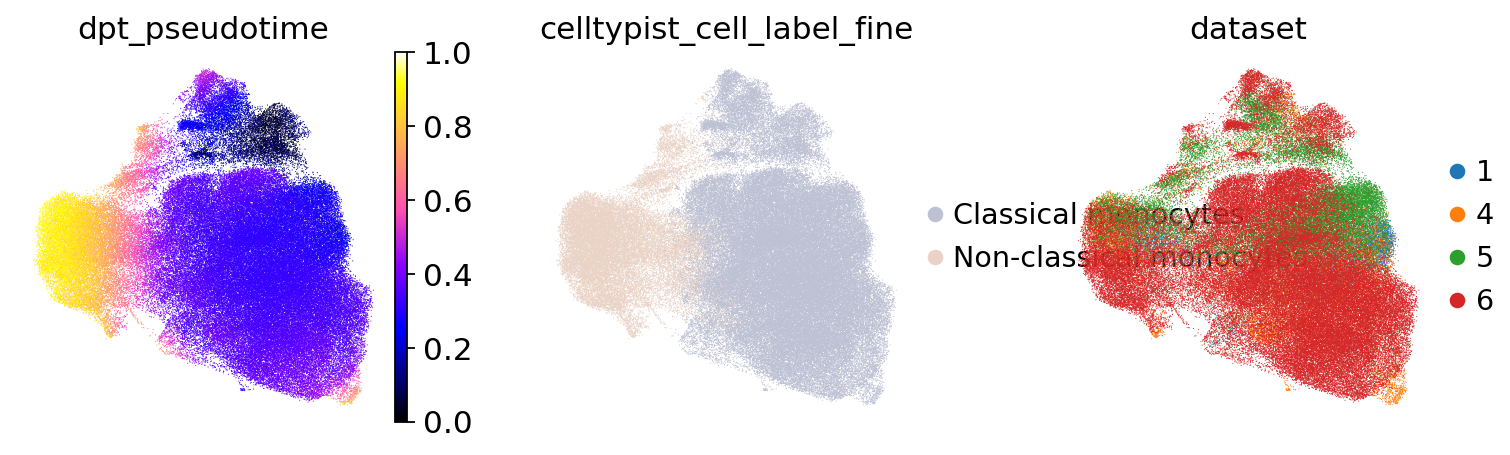

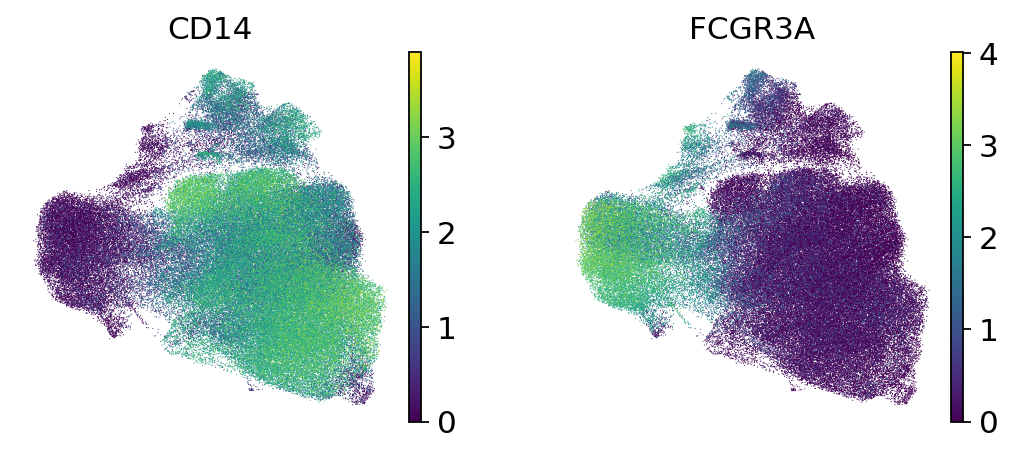

In [8]:
sc.pl.embedding(adata_mono, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")
# markers should form a gradient along pseudotime; dataset should be MIXED (not segregated)
sc.pl.embedding(adata_mono, basis="umap", color=["CD14", "FCGR3A"], layer="log1p_norm")

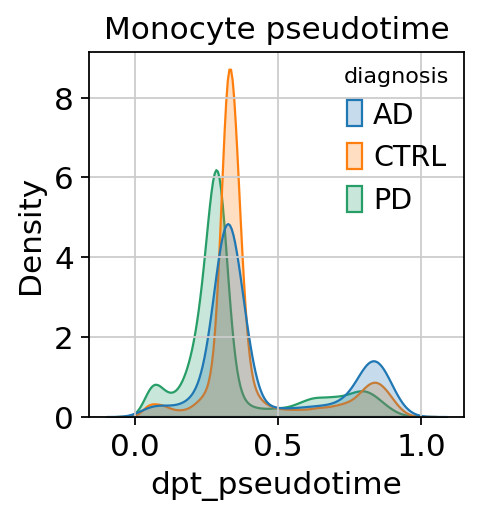

In [9]:
import seaborn as sns, matplotlib.pyplot as plt
sns.kdeplot(data=adata_mono.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("Monocyte pseudotime"); plt.show()


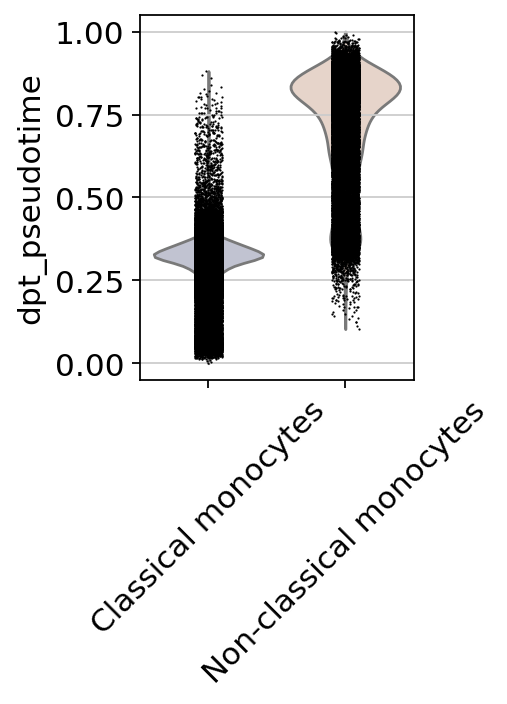

In [10]:
sc.pl.violin(
    adata_mono,
    keys=["dpt_pseudotime"],
    groupby="celltypist_cell_label_fine",
    rotation=45,
    order=[
        "Classical monocytes",
        "Non-classical monocytes",
    ],
)

In [11]:
adata.obs["celltypist_cell_label_fine"].value_counts()

celltypist_cell_label_fine
Tcm/Naive helper T cells       276082
CD16+ NK cells                 130968
Classical monocytes            100198
Tem/Temra cytotoxic T cells     95091
Tem/Effector helper T cells     61507
Tem/Trm cytotoxic T cells       46223
Naive B cells                   42217
Non-classical monocytes         27627
Memory B cells                  24084
Regulatory T cells              23014
Tcm/Naive cytotoxic T cells     17502
MAIT cells                      13022
DC2                              6313
NK cells                         4075
pDC                              3805
Monocytes                        3687
Age-associated B cells           3124
Megakaryocytes/platelets          710
Plasma cells                      471
HSC/MPP                           428
ILC3                              405
ETP                               172
DC1                               131
Megakaryocyte precursor            16
Name: count, dtype: int64

In [12]:
### T cell lineage (CD4 and CD8 split)

cd4 = ["Tcm/Naive helper T cells",     # naive/central memory -> root
       "Tem/Effector helper T cells"   # effector (terminal)
       ] 

cd8 = ["Tcm/Naive cytotoxic T cells",  # naive/early -> root
       "Tem/Temra cytotoxic T cells",  # effector memory (intermediate)
       "Tem/Trm cytotoxic T cells"   # TEMRA = terminally differentiated(late)
       ] 

# t_cells = ["Tcm/Naive helper T cells", "Tem/Temra cytotoxic T cells", "Tem/Effector helper T cells", "Tem/Trm cytotoxic T cells", "Regulatory T cells", "Tcm/Naive cytotoxic T cells", "MAIT cells"]
adata_cd4 = adata[adata.obs["celltypist_cell_label_fine"].isin(cd4)].copy()

adata_cd8 = adata[adata.obs["celltypist_cell_label_fine"].isin(cd8)].copy()


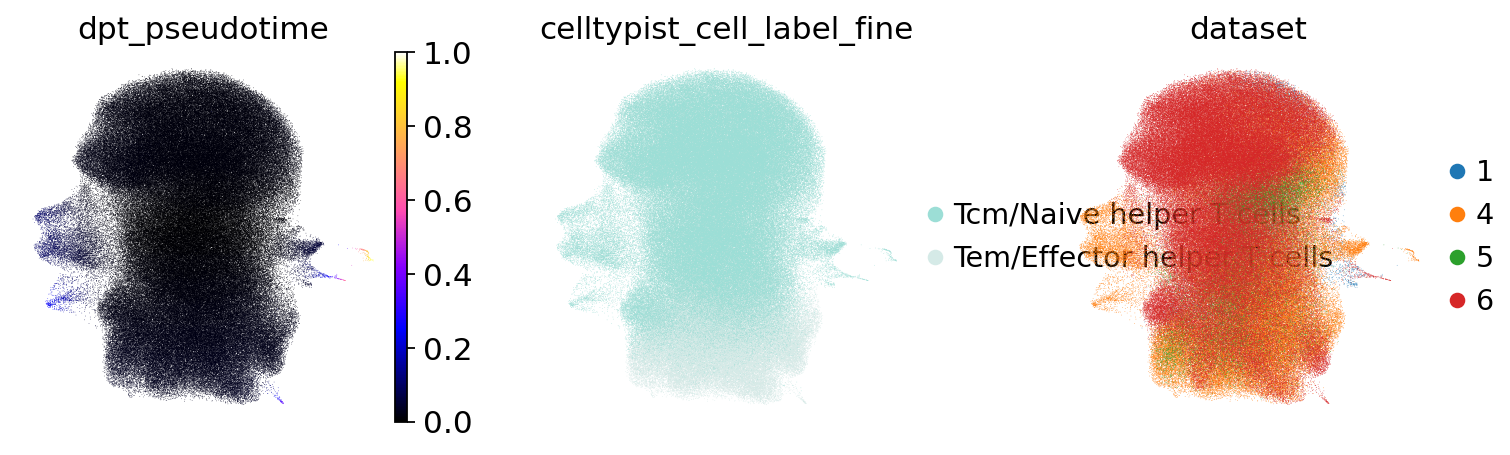

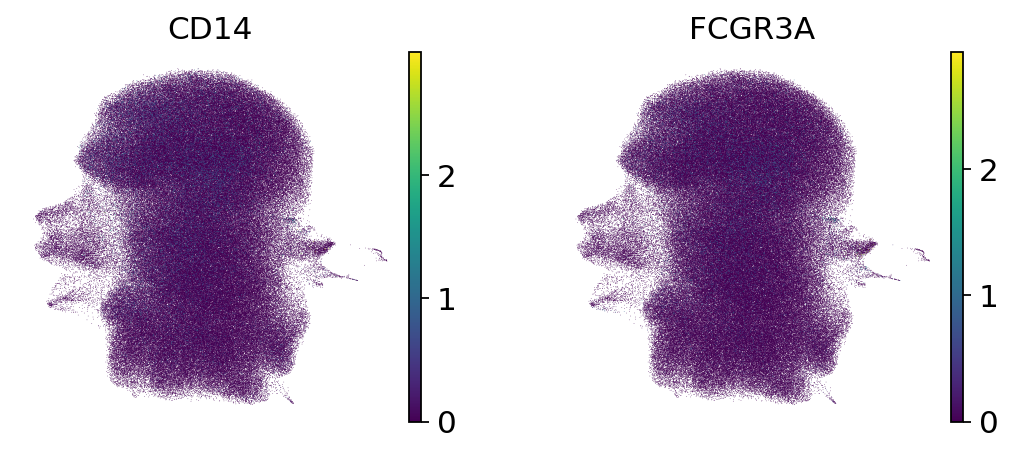

In [13]:
sc.pp.neighbors(adata_cd4, use_rep="X_scANVI") 
sc.tl.diffmap(adata_cd4) 

adata_cd4.uns["iroot"] = np.flatnonzero(
    adata_cd4.obs["celltypist_cell_label_fine"] == "Tcm/Naive helper T cells")[0]

sc.tl.dpt(adata_cd4) 
sc.tl.umap(adata_cd4)

sc.pl.embedding(adata_cd4, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")

sc.pl.embedding(adata_cd4, basis="umap", color=["CD14", "FCGR3A"], layer="log1p_norm")

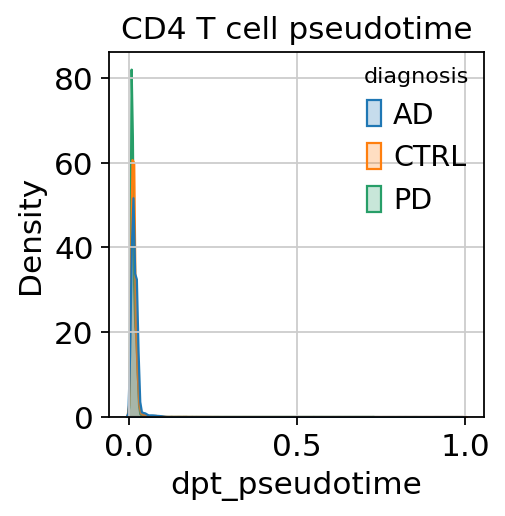

In [14]:
sns.kdeplot(data=adata_cd4.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("CD4 T cell pseudotime"); plt.show()

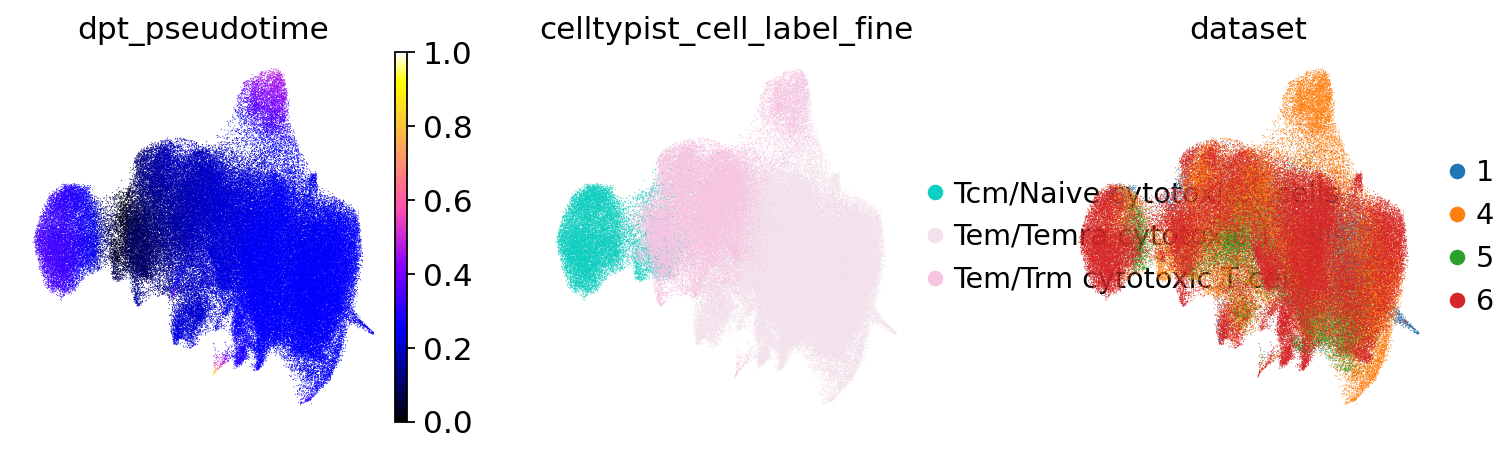

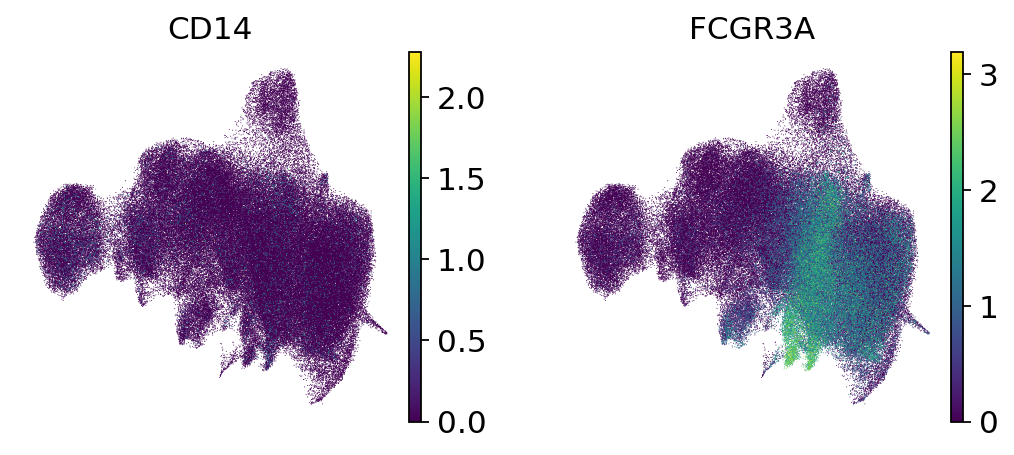

In [15]:
sc.pp.neighbors(adata_cd8, use_rep="X_scANVI") 
sc.tl.diffmap(adata_cd8) 

adata_cd8.uns["iroot"] = np.flatnonzero(
    adata_cd8.obs["celltypist_cell_label_fine"] == "Tcm/Naive cytotoxic T cells")[0]
sc.tl.dpt(adata_cd8) 
sc.tl.umap(adata_cd8)

sc.pl.embedding(adata_cd8, basis="umap",
                color=["dpt_pseudotime", "celltypist_cell_label_fine", "dataset"],
                color_map="gnuplot2")

sc.pl.embedding(adata_cd8, basis="umap", color=["CD14", "FCGR3A"], layer="log1p_norm")

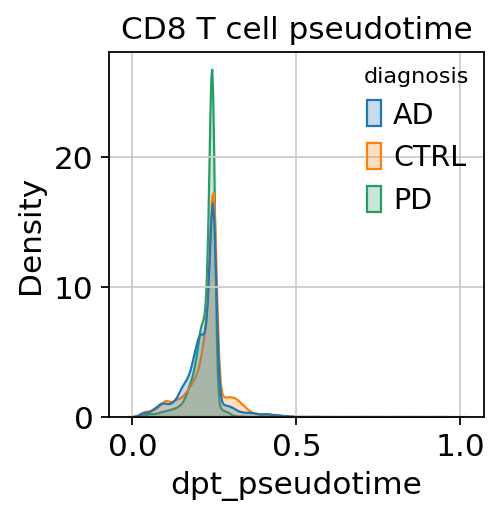

In [16]:
sns.kdeplot(data=adata_cd8.obs, x="dpt_pseudotime", hue="diagnosis", common_norm=False, fill=True)
plt.title("CD8 T cell pseudotime"); plt.show()
